# Proyecto AEMET - Despliegue en AWS EC2, NLP y FastAPI
---
¡Hola! En este notebook vamos a ver cómo hemos juntado todo el trabajo del proyecto para subirlo a la nube. 
El objetivo de esta fase ha sido **coger todas las piezas individuales** (el código de extracción, la web que hizo Tamara, nuestro modelo de NLP para hablar con la base de datos y los modelos predictivos) y **conectarlas de forma segura** en una máquina virtual de AWS EC2.

---
## Objetivos de este Notebook
1. **Organización del Código:** Explicar qué archivos están subidos a producción.
2. **Arquitectura Final:** Mostrar cómo se comunican la página web, nuestra API en FastAPI y la base de datos.
3. **Demostración NLP (Text-to-SQL):** Comprobar que podemos hacerle preguntas a la base de datos en lenguaje natural usando Google Gemini.
4. **Consulta de Históricos y Predicciones:** Ver cómo pedimos datos a la API para hacer gráficos y cómo le pedimos a XGBoost que prediga la temperatura máxima.
5. **Conclusión:** Resumir por qué lo hemos montado así.

---
### Imports necesarios para el Despliegue y Pruebas
---
### Sistema Operativo y Entorno
* **`os`**: Para acceder a variables de nuestro ordenador o servidor.
* **`dotenv.load_dotenv`**: Para cargar configuraciones (como contraseñas o IPs) desde un archivo `.env` sin que se vean en el código.

### Procesamiento y Análisis de Datos
* **`pandas` (como `pd`)**: Para guardar y manejar los datos que nos devuelve la API en formato de tabla (DataFrames).

### Conexión Web y APIs
* **`requests`**: Para poder hacer peticiones (GET o POST) a nuestra API de FastAPI.

### Visualización de Datos
* **`matplotlib.pyplot` / `seaborn`**: Para hacer gráficas chulas con los datos climáticos.
* **`IPython.display` (`display`)**: Para que las tablas de Pandas se vean bien bonitas en el notebook.

In [1]:
# Imports necesarios para probar el despliegue

import os
from dotenv import load_dotenv
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# Ocultamos warnings visuales para que el notebook quede más limpio
warnings.filterwarnings('ignore')

# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Paso 1: Configuración del Entorno de Conexión

Para simular lo que hace la página web (el frontend), necesitamos saber a qué IP de AWS EC2 tenemos que llamar.
Vamos a usar el archivo `.env` para cargar esta URL o, si no la encuentra, usaremos la IP pública que tenemos configurada por defecto.

In [2]:
# Cargamos las variables de entorno
load_dotenv()

# Buscamos la URL de nuestra API FastAPI. Si no está en el .env, usamos la de por defecto.
FASTAPI_URL = os.getenv("FASTAPI_URL", "http://18.198.208.67:8000")

print(f"Nos vamos a conectar a la API en: {FASTAPI_URL}")

Nos vamos a conectar a la API en: http://18.198.208.67:8000


## Paso 2: Organización del Código en la Nube

Para que podáis ver qué código está corriendo exactamente en AWS, he copiado los archivos en la carpeta `Despliegue_EC2/`.
Los archivos más importantes son:
- `api_unificada.py`: Es nuestro servidor **FastAPI**. Aquí nos conectamos a la base de datos PostgreSQL, cargamos los modelos de Machine Learning y usamos Gemini para entender las preguntas.
- `app_unificada.py`: Es nuestra página web hecha con **Streamlit**.
- `modelos_max/` y `modelos_min/`: Las carpetas donde guardamos los modelos entrenados (`.pkl`).

### Arquitectura de la Aplicación

Al separarlo así, la página web no tiene que hacer cálculos pesados ni conectarse directamente a la base de datos, lo que es mucho más seguro.

```mermaid
graph LR
    A[Usuario Final] -->|Entra a la web (Puerto 8501)| B(Streamlit - app_unificada)
    B -->|Llama a la API (Puerto 8000)| C{FastAPI Backend - api_unificada}
    C -->|Pide datos SQL (Puerto 5432)| D[(AWS RDS PostgreSQL)]
    C -->|Pregunta a Gemini| E[Google Gemini LLM]
    C -->|Hace predicciones| F[Modelos de Machine Learning]
```

## Paso 3: Demostración del Motor NLP (Text-to-SQL)

Aquí vamos a probar que Google Gemini funciona como nuestro analista virtual. 
Le mandamos una pregunta en español, el backend la traduce a SQL, saca los datos de la base de datos y nos los devuelve.

In [3]:
pregunta_usuario = "¿Cuáles fueron las 5 temperaturas máximas más altas registradas en Madrid durante el verano de 2023?"
print(f"Pregunta del usuario: '{pregunta_usuario}'\n")

try:
    print("Enviando pregunta a la API para procesar con Gemini...")
    # Simulamos la petición POST que haría Streamlit cuando le damos a 'Buscar'
    respuesta_nlp = requests.post(f"{FASTAPI_URL}/ask", json={"pregunta": pregunta_usuario}, timeout=20)
    
    if respuesta_nlp.status_code == 200:
        datos_respuesta = respuesta_nlp.json()
        print("Traducción a SQL y consulta a base de datos completadas.\n")
        print(f"SQL Generado internamente:\n{datos_respuesta.get('sql_generado')}\n")
        
        # Convertimos la respuesta a un DataFrame para visualizarlo en el notebook
        df_nlp = pd.DataFrame(datos_respuesta.get('datos', []))
        print("Resultados obtenidos listos para mostrar:")
        display(df_nlp.head())
    else:
        print(f"Error de la API: Código {respuesta_nlp.status_code} - {respuesta_nlp.text}")

except requests.exceptions.Timeout:
    print("Error: La API tardó demasiado en responder (Timeout).")
except requests.exceptions.RequestException as e:
    print(f"Error de conexión a EC2: {e}")

Pregunta del usuario: '¿Cuáles fueron las 5 temperaturas máximas más altas registradas en Madrid durante el verano de 2023?'

Enviando pregunta a la API para procesar con Gemini...
Traducción a SQL y consulta a base de datos completadas.

SQL Generado internamente:
SELECT fecha, tmax FROM datos_climaticos WHERE provincia ILIKE '%madrid%' AND fecha BETWEEN '2023-06-21' AND '2023-09-23' ORDER BY tmax DESC LIMIT 5

Resultados obtenidos listos para mostrar:


,fecha,tmax
0,2023-06-23,None
1,2023-06-21,None
2,2023-06-21,None
3,2023-06-22,None
4,2023-06-24,None


## Paso 4: Consumo de Históricos y Predicciones ML (XGBoost)

Nuestra API también sirve los modelos predictivos y los datos históricos. 
Vamos a probar a descargar los datos de una estación durante un mes, pintarlos, y luego pedirle al modelo que prediga la temperatura máxima basándose en la última lectura de temperatura media.

Obteniendo histórico para la estación 3195 (2024-01-01 al 2024-01-31)...


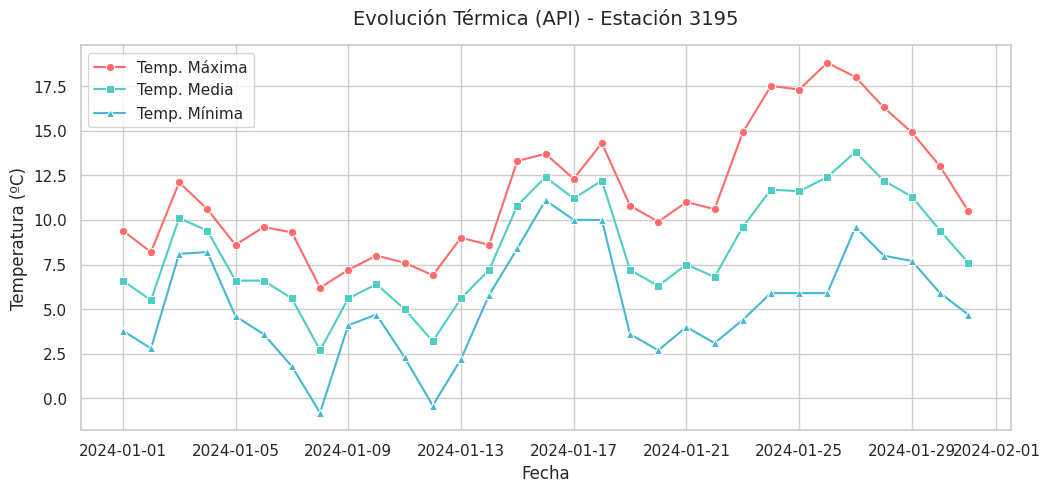


Pidiendo predicción en tiempo real al modelo XGBoost...
Ok. Con una T. Media actual de 31.8ºC, el modelo predice una T. Máxima de 36.19ºC


In [4]:
indicativo_estacion = "3195" # Estación Madrid, Retiro
fecha_ini_prueba = "2024-01-01"
fecha_fin_prueba = "2024-01-31"

try:
    # 1. Obtenemos el histórico de datos
    print(f"Obteniendo histórico para la estación {indicativo_estacion} ({fecha_ini_prueba} al {fecha_fin_prueba})...")
    res_hist = requests.get(f"{FASTAPI_URL}/historico/obtener_historico", 
                            params={"id": indicativo_estacion, "fecha_inicio": fecha_ini_prueba, "fecha_fin": fecha_fin_prueba},
                            timeout=15)
    
    if res_hist.status_code == 200:
        # Cargamos y preparamos los datos en Pandas
        df_hist = pd.DataFrame(res_hist.json().get("registros", []))
        if not df_hist.empty:
            df_hist['fecha'] = pd.to_datetime(df_hist['fecha'])
            
            # Graficamos la evolución térmica
            plt.figure(figsize=(12, 5))
            sns.lineplot(data=df_hist, x='fecha', y='tmax', marker="o", label="Temp. Máxima", color="#ff6b6b")
            sns.lineplot(data=df_hist, x='fecha', y='tmed', marker="s", label="Temp. Media", color="#4ecdc4")
            sns.lineplot(data=df_hist, x='fecha', y='tmin', marker="^", label="Temp. Mínima", color="#45b7d1")
            
            plt.title(f"Evolución Térmica (API) - Estación {indicativo_estacion}", fontsize=14, pad=15)
            plt.xlabel("Fecha")
            plt.ylabel("Temperatura (ºC)")
            plt.legend()
            plt.show()
        else:
            print("La API no devolvió registros para este rango de fechas.")
        
        # 2. Petición al modelo de ML
        print("\nPidiendo predicción en tiempo real al modelo XGBoost...")
        res_ult = requests.get(f"{FASTAPI_URL}/historico/ultima_tmed", params={"id": indicativo_estacion}, timeout=10)
        
        if res_ult.status_code == 200:
            ultima_tmed = res_ult.json().get('tmed')
            if ultima_tmed is not None:
                # Enviamos la temperatura media al modelo para que haga la predicción
                res_pred = requests.post(f"{FASTAPI_URL}/modelos_max/{indicativo_estacion}/predict", 
                                         json={"features": [ultima_tmed]}, timeout=10)
                
                if res_pred.status_code == 200:
                    prediccion = res_pred.json().get('prediccion', [[None]])[0][0]
                    print(f"Ok. Con una T. Media actual de {ultima_tmed}ºC, el modelo predice una T. Máxima de {prediccion:.2f}ºC")
                else:
                    print(f"Error al predecir: Código {res_pred.status_code}")
            else:
                print("No se pudo obtener la última temperatura media.")
        else:
            print(f"Error al obtener la última medición: Código {res_ult.status_code}")
    else:
         print(f"Error al obtener histórico: Código {res_hist.status_code} - {res_hist.text}")
            
except requests.exceptions.RequestException as e:
    print(f"Error general de conexión: {e}")

## Paso 5: Conclusión de la Integración

El principal reto de esta parte ha sido **separar el frontend de los datos**. Al principio, nuestros notebooks se conectaban directamente a la base de datos o corrían los modelos directamente en memoria.

Al poner **FastAPI** en medio (como un intermediario en AWS EC2):
1. **Seguridad:** Las contraseñas de la base de datos y de Google Gemini solo están en el servidor, no en la web del usuario.
2. **Rendimiento:** FastAPI carga los modelos de Machine Learning (que son pesados) en memoria una sola vez al arrancar el servidor.
3. **Sencillez:** La página web con **Streamlit** solo se encarga de dibujar botoncitos y gráficas con los datos que le llegan por internet.

*(Puedes ver el código completo de todo esto en los archivos de la carpeta `Despliegue_EC2/`)*.